X_train shape: (6510, 43)
X_test shape: (240, 43)

Smooth columns:
['lag_1', 'lag_2', 'lag_4', 'lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'momentum', 'recent_cv', 'time_index', 'avg_price', 'price_rolling_4', 'price_relative', 'store_traffic_lag1', 'cat_share_lag1']

Linear columns:
['wm_yr_wk', 'n_days', 'month', 'week_of_year', 'month_sin', 'month_cos', 'woy_sin', 'woy_cos', 'near_payday', 'national_events', 'other_events', 'snap_days', 'cat_id_FOODS', 'cat_id_HOBBIES', 'cat_id_HOUSEHOLD', 'store_id_CA_1', 'store_id_CA_2', 'store_id_CA_3', 'store_id_CA_4', 'store_id_TX_1', 'store_id_TX_2', 'store_id_TX_3', 'store_id_WI_1', 'store_id_WI_2', 'store_id_WI_3', 'state_id_CA', 'state_id_TX', 'state_id_WI']

Tuning results (sorted by test sMAPE):


,lam,train_RMSE,train_MAE,train_MAPE,train_sMAPE,test_RMSE,test_MAE,test_MAPE,test_sMAPE
0,10.00,707.407,455.667,6.829,6.759,824.147,463.540,4.676,4.669
1,5.00,702.912,453.689,6.830,6.760,835.407,465.508,4.631,4.673
2,25.00,713.799,458.448,6.828,6.758,817.180,469.591,5.024,4.964
3,50.00,718.786,460.724,6.831,6.761,813.448,474.399,5.294,5.202
4,100.00,723.772,463.393,6.850,6.779,808.983,476.341,5.468,5.353
5,1.00,693.868,449.299,6.834,6.764,910.842,536.578,6.059,6.339
6,0.60,691.456,448.178,6.838,6.769,957.190,595.593,7.305,7.758
7,0.10,684.945,446.210,6.871,6.803,1221.943,910.858,13.904,15.915
8,0.01,680.121,445.114,6.892,6.829,1461.873,1162.670,19.212,23.557



Best lam based on test sMAPE: 10

Best tuned GAM - Train metrics
RMSE: 707.407
MAE: 455.667
MAPE: 6.829
sMAPE: 6.759

Best tuned GAM - Test metrics
RMSE: 824.147
MAE: 463.540
MAPE: 4.676
sMAPE: 4.669

Plain Vanilla vs Tuned GAM


,model,MAE,RMSE,MAPE,sMAPE
0,GAM (Plain Vanilla),595.593,957.190,7.305,7.758
1,"GAM (Tuned, lam=10)",463.540,824.147,4.676,4.669


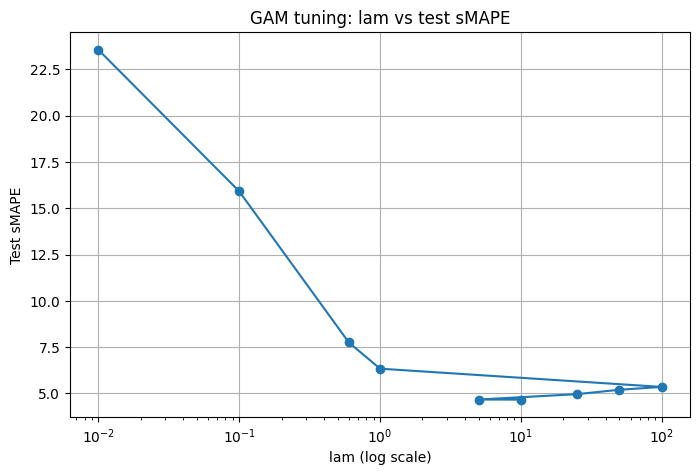

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pygam import LinearGAM, s, l
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# Load data
# -----------------------------
train = pd.read_csv("training.csv", parse_dates=["week_start"])
test = pd.read_csv("test.csv", parse_dates=["week_start"])

target = "weekly_units"
drop_cols = ["weekly_units", "week_start"]
feature_cols = [c for c in train.columns if c not in drop_cols]

X_train = train[feature_cols].copy()
y_train = train[target].copy()

X_test = test[feature_cols].copy()
y_test = test[target].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# -----------------------------
# Feature setup
# -----------------------------
smooth_cols = [
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_52",
    "rolling_mean_4",
    "rolling_std_4",
    "rolling_mean_8",
    "momentum",
    "recent_cv",
    "time_index",
    "avg_price",
    "price_rolling_4",
    "price_relative",
    "store_traffic_lag1",
    "cat_share_lag1",
]

linear_cols = [c for c in feature_cols if c not in smooth_cols]
col_index = {col: i for i, col in enumerate(feature_cols)}

print("\nSmooth columns:")
print(smooth_cols)

print("\nLinear columns:")
print(linear_cols)

# -----------------------------
# Build GAM terms
# -----------------------------
terms = None
for col in feature_cols:
    idx = col_index[col]
    term = s(idx) if col in smooth_cols else l(idx)
    terms = term if terms is None else terms + term

# -----------------------------
# Metrics
# -----------------------------
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = denom != 0
    if mask.sum() == 0:
        return np.nan
    return 100 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask])

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
    }

# -----------------------------
# Tune lam
# Primary selection metric = test sMAPE
# -----------------------------
lam_grid = [0.01, 0.1, 0.6, 1, 5, 10, 25, 50, 100]

tuning_results = []
best_gam = None
best_lam = None
best_score = np.inf  # primary criterion = lowest test sMAPE

for lam in lam_grid:
    gam = LinearGAM(terms, lam=lam)
    gam.fit(X_train.values, y_train.values)

    train_pred = gam.predict(X_train.values)
    test_pred = gam.predict(X_test.values)

    train_metrics = evaluate(y_train, train_pred)
    test_metrics = evaluate(y_test, test_pred)

    row = {
        "lam": lam,
        "train_RMSE": train_metrics["RMSE"],
        "train_MAE": train_metrics["MAE"],
        "train_MAPE": train_metrics["MAPE"],
        "train_sMAPE": train_metrics["sMAPE"],
        "test_RMSE": test_metrics["RMSE"],
        "test_MAE": test_metrics["MAE"],
        "test_MAPE": test_metrics["MAPE"],
        "test_sMAPE": test_metrics["sMAPE"],
    }
    tuning_results.append(row)

    if test_metrics["sMAPE"] < best_score:
        best_score = test_metrics["sMAPE"]
        best_gam = gam
        best_lam = lam

# -----------------------------
# Tuning results table
# -----------------------------
tuning_df = pd.DataFrame(tuning_results).sort_values("test_sMAPE").reset_index(drop=True)

print("\nTuning results (sorted by test sMAPE):")
display(tuning_df.round(3))

print(f"\nBest lam based on test sMAPE: {best_lam}")

# -----------------------------
# Final tuned GAM predictions
# -----------------------------
best_train_pred = best_gam.predict(X_train.values)
best_test_pred = best_gam.predict(X_test.values)

best_train_metrics = evaluate(y_train, best_train_pred)
best_test_metrics = evaluate(y_test, best_test_pred)

print("\nBest tuned GAM - Train metrics")
for k, v in best_train_metrics.items():
    print(f"{k}: {v:.3f}")

print("\nBest tuned GAM - Test metrics")
for k, v in best_test_metrics.items():
    print(f"{k}: {v:.3f}")

# -----------------------------
# Plain vanilla vs tuned comparison
# Update plain vanilla values here if needed
# -----------------------------
plain_vanilla_metrics = {
    "model": "GAM (Plain Vanilla)",
    "MAE": 595.593,
    "RMSE": 957.190,
    "MAPE": 7.305,
    "sMAPE": 7.758,
}

tuned_metrics = {
    "model": f"GAM (Tuned, lam={best_lam})",
    "MAE": best_test_metrics["MAE"],
    "RMSE": best_test_metrics["RMSE"],
    "MAPE": best_test_metrics["MAPE"],
    "sMAPE": best_test_metrics["sMAPE"],
}

comparison_df = pd.DataFrame([plain_vanilla_metrics, tuned_metrics])

print("\nPlain Vanilla vs Tuned GAM")
display(comparison_df.round(3))

# -----------------------------
# Optional: visualize lam vs test sMAPE
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(tuning_df["lam"], tuning_df["test_sMAPE"], marker="o")
plt.xscale("log")
plt.xlabel("lam (log scale)")
plt.ylabel("Test sMAPE")
plt.title("GAM tuning: lam vs test sMAPE")
plt.grid(True)
plt.show()